In [59]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# PREDICTING THE PERFORMANCE OF THE STUDENTS

In [60]:
# reading the csv file 
student_df = pd.read_csv('./studentf.csv')

# analyzing

In [61]:
student_df.sample(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
117,13,84,Medium,Medium,No,5,78,Medium,Yes,1,Low,High,Public,Positive,2,No,High School,Near,Male,65
3061,18,85,Medium,High,No,7,69,Medium,Yes,2,Low,Medium,Private,Positive,4,No,High School,Near,Male,68
972,25,77,Low,Medium,Yes,7,71,Medium,Yes,0,Medium,Medium,Public,Negative,3,No,High School,Near,Female,66
5979,23,91,Medium,High,Yes,7,75,Low,Yes,2,Low,High,Public,Negative,2,No,High School,Far,Male,69
2406,12,76,Medium,Low,Yes,4,51,Medium,Yes,0,Low,Medium,Private,Neutral,1,No,High School,Near,Female,60


In [62]:
round(student_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.98,5.99,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.98,11.55,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.03,1.47,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.07,14.40,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.49,1.23,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.97,1.03,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.24,3.89,55.0,65.0,67.0,69.0,101.0


In [63]:
student_df[student_df['Exam_Score'] == 101]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


* the data might have some outliers 

In [64]:
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [65]:
# checking for null values
student_df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

* only 3 columns have null values 

# VISUALIZATION ANALYSIS

<Axes: xlabel='Gender', ylabel='Attendance'>

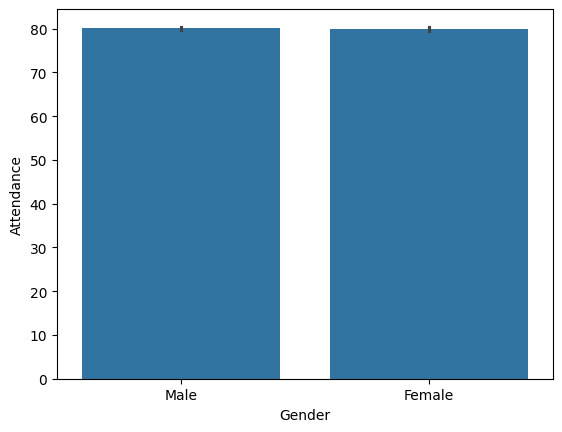

In [66]:
sns.barplot(data = student_df,x = 'Gender',y = 'Attendance')

* THE ATTENDANCE IS SAME FOR BOTH MALE AND FEMALE STUDENTS

<Axes: title={'center': 'How is Parental Involvement effecting the marks'}, xlabel='Parental_Involvement', ylabel='Exam_Score'>

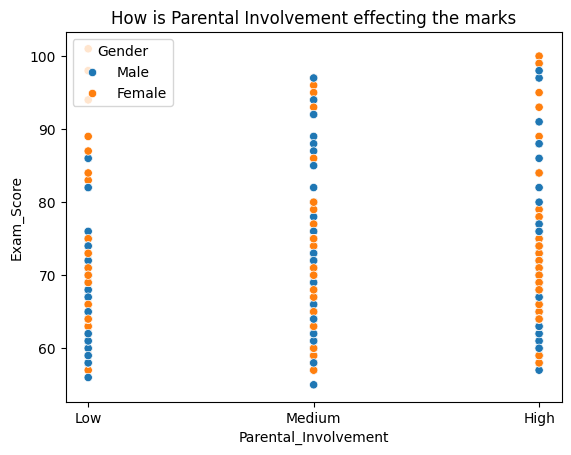

In [67]:
plt.title("How is Parental Involvement effecting the marks")
sns.scatterplot(data = student_df, y = 'Exam_Score', x = 'Parental_Involvement', hue = 'Gender')

* students who have more parental involvement scored a little bit higher

<Axes: xlabel='Exam_Score', ylabel='Hours_Studied'>

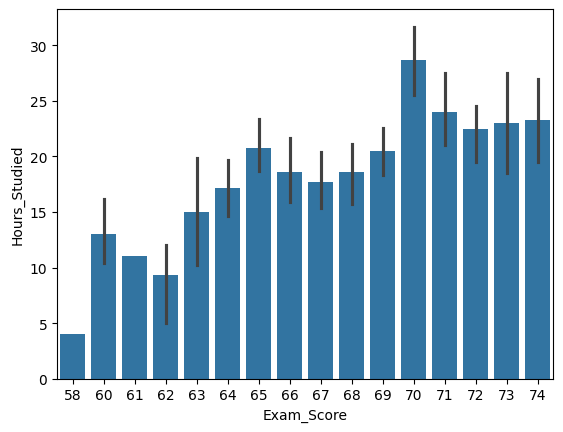

In [68]:
sns.barplot(data = student_df.sample(100).sort_values(by = 'Exam_Score', ascending=False), x = 'Exam_Score', y = 'Hours_Studied')

* THIS SHOWS SOME INTERESTING TRENDS. EVEN THOUGH SOME STUDIED FOR LESS HOURS STILL THEY SCORED MORE IN THEIR EXAMS

<Axes: xlabel='School_Type', ylabel='Exam_Score'>

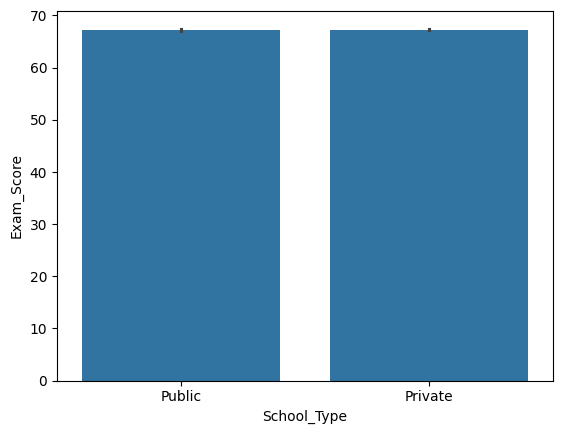

In [69]:
sns.barplot(student_df,x = 'School_Type' , y = 'Exam_Score')

In [70]:
categorical = student_df.select_dtypes(include = 'object').columns.tolist()

for cols in categorical:
    uni = student_df[cols].value_counts()
    print(f'Cols : {cols}')
    print(f"Unique_value : {uni}")

Cols : Parental_Involvement
Unique_value : Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64
Cols : Access_to_Resources
Unique_value : Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64
Cols : Extracurricular_Activities
Unique_value : Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64
Cols : Motivation_Level
Unique_value : Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64
Cols : Internet_Access
Unique_value : Internet_Access
Yes    6108
No      499
Name: count, dtype: int64
Cols : Family_Income
Unique_value : Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64
Cols : Teacher_Quality
Unique_value : Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64
Cols : School_Type
Unique_value : School_Type
Public     4598
Private    2009
Name: count, dtype: int64
Cols : Peer_Influence
Uni

* copying the data so later we can have scaled data for baseline model and unscaled for tree based model

In [71]:
scaled_df = student_df.copy()
scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [72]:
scaled_df['Teacher_Quality'] = scaled_df['Teacher_Quality'].fillna(scaled_df['Teacher_Quality'].mode()[0])
# filling the null values 

In [73]:
low_med_high = {'Low' : 0, 'Medium' : 1, 'High' : 2}
y_and_n = {'Yes' : 1,'No' : 0}

for cols in categorical:
    uni = set(scaled_df[cols].unique())
    if uni.issubset({'Low','Medium','High'}):
        scaled_df[cols] = scaled_df[cols].map(low_med_high)
    elif uni.issubset({'Yes','No'}):
        scaled_df[cols] = scaled_df[cols].map(y_and_n)


In [74]:
scaled_df[categorical].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Parental_Involvement        6607 non-null   int64 
 1   Access_to_Resources         6607 non-null   int64 
 2   Extracurricular_Activities  6607 non-null   int64 
 3   Motivation_Level            6607 non-null   int64 
 4   Internet_Access             6607 non-null   int64 
 5   Family_Income               6607 non-null   int64 
 6   Teacher_Quality             6607 non-null   int64 
 7   School_Type                 6607 non-null   object
 8   Peer_Influence              6607 non-null   object
 9   Learning_Disabilities       6607 non-null   int64 
 10  Parental_Education_Level    6517 non-null   object
 11  Distance_from_Home          6540 non-null   object
 12  Gender                      6607 non-null   object
dtypes: int64(8), object(5)
memory usage: 671.2+ KB


* we have 5 more columns. 2 can be mapped. However Parental_Education_Level  and Distance_from_Home have null values that might hinder us. So it is for the best to use one-hot encoder on the rest 3 columns

In [75]:
scaled_df['School_Type'] = scaled_df['School_Type'].map({"Private" : 1,"Public" : 0})
scaled_df['Gender'] = scaled_df['Gender'].map({"Male" : 0 , "Female" : 1})

* Peer_Influence has no natural order (Positive, Negative, Neutral)

In [76]:
e_cols = ['Parental_Education_Level','Distance_from_Home','Peer_Influence']

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(scaled_df[e_cols])
encoded_cols = list(encoder.get_feature_names_out(e_cols))
scaled_df[encoded_cols] = encoder.transform(scaled_df[e_cols])

# droping the e_cols
scaled_df.drop(columns = e_cols,inplace = True)

In [77]:
num_list = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Tutoring_Sessions','Physical_Activity']

scaled_df[num_list].isna().sum()

Hours_Studied        0
Attendance           0
Sleep_Hours          0
Previous_Scores      0
Tutoring_Sessions    0
Physical_Activity    0
dtype: int64

In [78]:
scaled_df[num_list].skew()
# data is not skewed so we are good to go 

Hours_Studied        0.013499
Attendance           0.013666
Sleep_Hours         -0.023805
Previous_Scores     -0.003737
Tutoring_Sessions    0.815530
Physical_Activity   -0.031365
dtype: float64

In [80]:
# dividing into X and Y
X = scaled_df.drop('Exam_Score',axis = 1)
Y = scaled_df['Exam_Score']

print(X.shape)
print(Y.shape)

(6607, 27)
(6607,)


In [84]:
from sklearn.model_selection import KFold, cross_val_score,cross_val_predict
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [95]:
def train_model(model,name,X,y,scale = True):
    if scale == True:
        pipe = Pipeline([
            ('scaler',StandardScaler()),
            ('model',model)
        ])
    else:
        pipe = Pipeline([
            ('model',model)
        ])

    k = KFold(n_splits=5,shuffle=True,random_state=42)
    
    # R²
    r2_scores = cross_val_score(pipe, X, Y, cv=k, scoring='r2')
    print(f'The R2 mean score : {r2_scores.mean()}, The R2 std score : {r2_scores.std()}')

    # RMSE — note the neg_ prefix, sklearn returns negative so you negate it
    rmse_scores = cross_val_score(pipe, X, Y, cv=k, scoring='neg_root_mean_squared_error')
    print(f'The RMSE score : {-rmse_scores.mean()}')

    # MAE
    mae_scores = cross_val_score(pipe, X, Y, cv=k, scoring='neg_mean_absolute_error')
    print(f'The MAE score : {-mae_scores.mean()}')


# TRAINING THE MODELS

In [96]:
lasso_model = Lasso(
    alpha=1.0,          # regularization strength (default=1.0)
    fit_intercept=True,
    max_iter=1000,             
)
train_model(lasso_model,'Lasso Regression',X,Y,scale = True)

The R2 mean score : 0.4134509533761544, The R2 std score : 0.05629737749723591
The RMSE score : 2.976980799310984
The MAE score : 1.9475368036545881


In [97]:
ridge_model = Ridge(
    alpha=1.0,          # regularization strength (default=1.0)
    fit_intercept=True,
    max_iter=None,      
)
train_model(ridge_model,'Ridge Regression',X,Y,scale = True)

The R2 mean score : 0.7375744644825285, The R2 std score : 0.10153358826690251
The RMSE score : 1.9698384267810738
The MAE score : 0.482544345086824


In [98]:
lr_model = LinearRegression()
train_model(lr_model,'Linear Regression',X,Y,scale = True)

The R2 mean score : 0.7375736951706628, The R2 std score : 0.10153430819802187
The RMSE score : 1.9698400965561724
The MAE score : 0.4825337392185956


In [99]:
tree_model = DecisionTreeRegressor(random_state=42,max_depth = 7)
train_model(tree_model,'Decision Tree',X,Y,scale = False)

The R2 mean score : 0.4257822962069236, The R2 std score : 0.06539152529041369
The RMSE score : 2.942975431611096
The MAE score : 1.6607217965756937


In [100]:
tree_model = DecisionTreeRegressor(random_state=42,max_depth = 5)
train_model(tree_model,'Decision Tree',X,Y,scale = False)

The R2 mean score : 0.5091216203741438, The R2 std score : 0.07960365724514108
The RMSE score : 2.721628462100858
The MAE score : 1.6632750598088861


In [101]:
forest_model = RandomForestRegressor(random_state=42,n_jobs = -1 , n_estimators=100)
train_model(forest_model,'Random Forest',X,Y,scale = False)

The R2 mean score : 0.6456664592734651, The R2 std score : 0.08873498087914533
The RMSE score : 2.307787969285368
The MAE score : 1.1183248891123374
